In [1]:
import mne
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

In [2]:
path_to_dir = Path("/storage/cedar/cedar_cos/cos-lab-aivanova7/eayesh3/iEEG/EMOP0004/tasks_raw")
eeg_file = "sub-EMOP0004_ses-ieeg1_task-language_acq-4_run-1_ieeg.edf"
path_to_eeg = path_to_dir/eeg_file

In [3]:
raw = mne.io.read_raw_edf(path_to_eeg, preload=True)

Extracting EDF parameters from /storage/cedar/cedar_cos/cos-lab-aivanova7/eayesh3/iEEG/EMOP0004/tasks_raw/sub-EMOP0004_ses-ieeg1_task-language_acq-4_run-1_ieeg.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 11150015  =      0.000 ...  5444.343 secs...


/tmp/ipykernel_1562452/1845282016.py:1: RuntimeWarning: Omitted 6 annotation(s) that were outside data range.
  raw = mne.io.read_raw_edf(path_to_eeg, preload=True)


In [4]:
import re
ch_names = raw.ch_names
ch_IDs = sorted(set(re.sub(r'\d+$', '', ch) for ch in ch_names))
print(ch_IDs)
lh_channels = [ch for ch in ch_IDs if ch[0].lower() == "l"]
rh_channels = [ch for ch in ch_IDs if ch[0].lower() == "r"]
eeg_ch_set = lh_channels + rh_channels

eeg_channels= [ch for ch in ch_names if re.sub(r'\d+$', '', ch) in eeg_ch_set]

raw.set_channel_types({ch:"seeg" for ch in eeg_channels})
print(raw.get_channel_types(picks=250))

['DC', 'EKG', 'LAHc', 'LAIn', 'LAm', 'LEc', 'LMiHc', 'LMiIn', 'LOFc', 'LPHG', 'LPul', 'LTePo', 'OSAT', 'PR', 'Pleth', 'RAHc', 'RAIn', 'RANT', 'RAm', 'REc', 'RMiHc', 'ROFc', 'RPHG', 'RPuI', 'RTePo', 'TRIG']
['seeg']


In [5]:
raw.resample(200)

<RawEDF | sub-EMOP0004_ses-ieeg1_task-language_acq-4_run-1_ieeg.edf, 276 x 1088869 (5444.3 s), ~2.24 GiB, data loaded>

Using matplotlib as 2D backend.


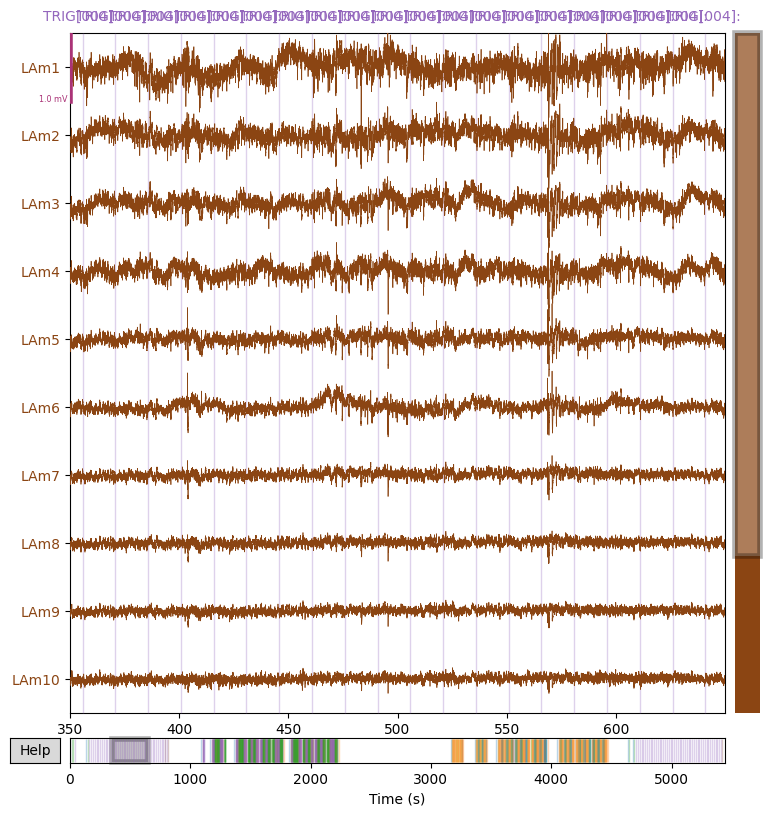

In [6]:

# before filtering
raw.plot(
    picks=eeg_channels[0:13],
    duration=300,   # seconds shown at once
    start=350,       # start time in seconds
    n_channels=10,  # how many stacked traces
    scalings={"seeg": 500e-6}
);

In [7]:
# 8th order type-II (stop-band ripple) Chebyshev filter
iir_params = dict(
    order=8,
    ftype="cheby2",
    rs=60
)

raw_filter = raw.copy().filter(
    l_freq=10,
    h_freq=60,
    method="iir",
    iir_params=iir_params,
    picks="seeg"
)

Filtering a subset of channels. The highpass and lowpass values in the measurement info will not be updated.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 10 - 60 Hz

IIR filter parameters
---------------------
Chebyshev II bandpass zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 32 (effective, after forward-backward)
- Cutoffs at 10.00, 60.00 Hz: -120.00, -120.00 dB



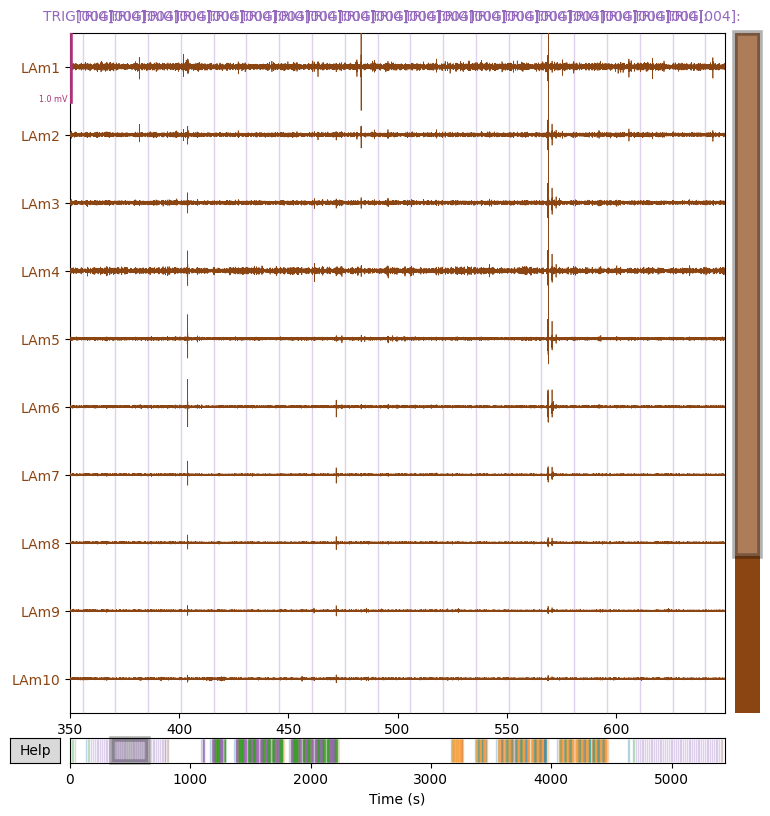

In [8]:
raw_filter.plot(
    picks=eeg_channels[0:13],
    duration=300,   # seconds shown at once
    start=350,       # start time in seconds
    n_channels=10,  # how many stacked traces
    scalings={"seeg": 500e-6}
);

### Notch filtering for line


In [9]:
#notch biquad filter from the paper

fs = raw_filter.info["sfreq"]
f0 = 60
r = 0.985

# -----------------------------
# Build custom biquad notch
# -----------------------------
w0 = 2 * np.pi * f0 / fs
b_custom = np.array([1.0, -2 * np.cos(w0), 1.0])
a_custom = np.array([1.0, -2 * r * np.cos(w0), r**2])

# Optional normalization to unity gain at DC
_, h0 = signal.freqz(b_custom, a_custom, worN=[0], fs=fs)
b_custom = b_custom / np.abs(h0[0])

# -----------------------------
# Pick only SEEG channels
# -----------------------------
seeg_picks = mne.pick_types(raw_filter.info, seeg=True)

# Get all data
data = raw_filter.get_data()

# Make copies so non-SEEG channels stay unchanged
data_filt_zero = data.copy()

# -----------------------------
# Filter only SEEG channels
# -----------------------------

data_filt_zero[seeg_picks, :] = signal.filtfilt(
    b_custom, a_custom, data[seeg_picks, :], axis=-1
)

# Put filtered data back into Raw copies

raw_zero = raw.copy()
raw_zero._data = data_filt_zero

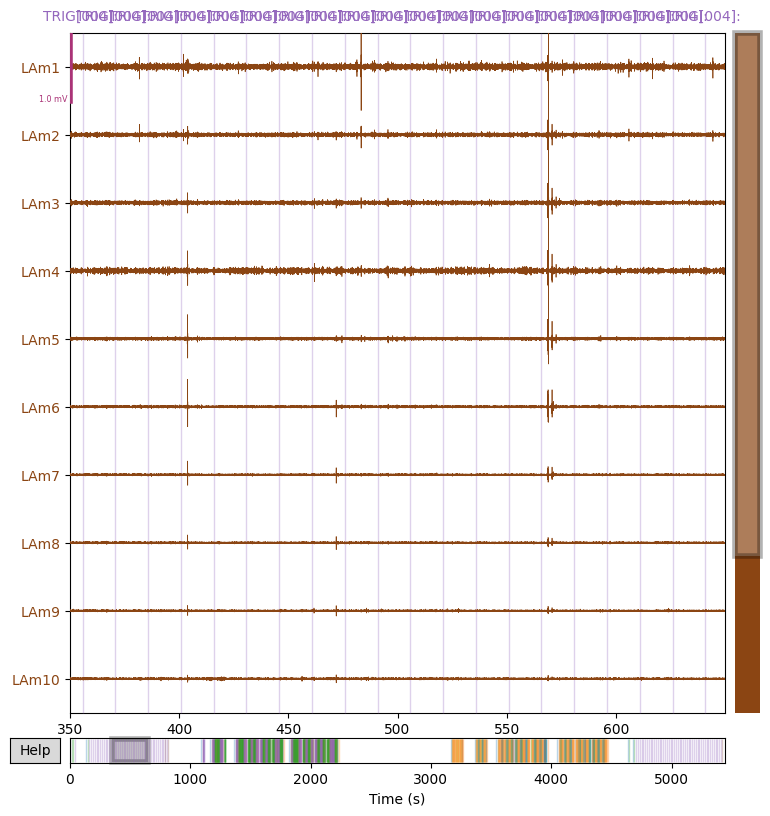

In [10]:
raw_zero.plot(
    picks=eeg_channels[0:13],
    duration=300,   # seconds shown at once
    start=350,       # start time in seconds
    n_channels=10,  # how many stacked traces
    scalings={"seeg": 500e-6}
);

In [11]:
raw_filter2 = raw_filter.copy().notch_filter(
    freqs=[60],
    method="iir",
    picks="seeg"
)

Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 59 - 61 Hz

IIR filter parameters
---------------------
Butterworth bandstop zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 16 (effective, after forward-backward)
- Cutoffs at 59.35, 60.65 Hz: -6.02, -6.02 dB



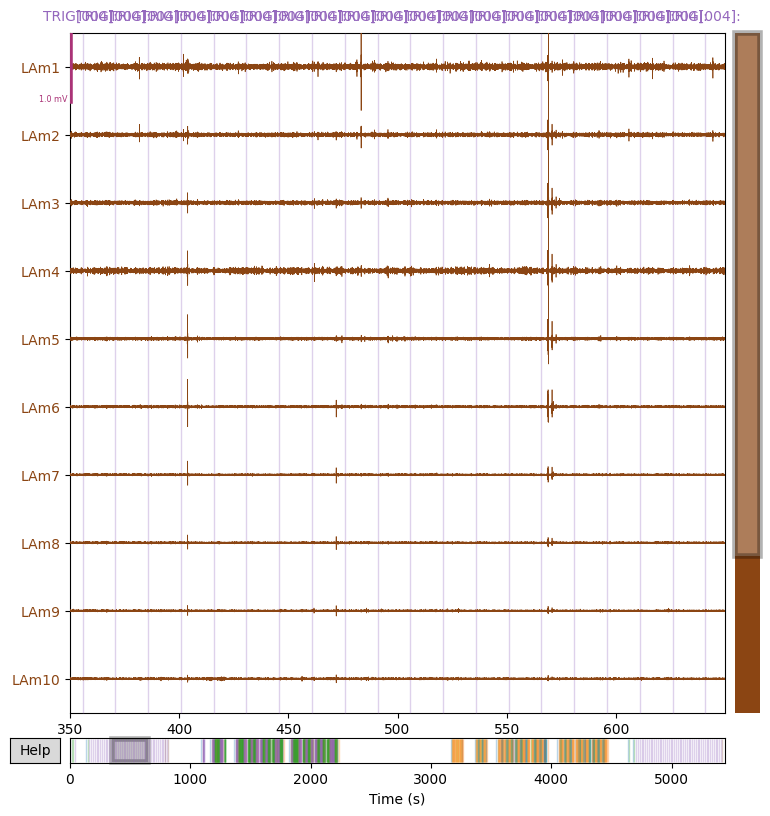

In [12]:
raw_filter2.plot(
    picks=eeg_channels[0:13],
    duration=300,   # seconds shown at once
    start=350,       # start time in seconds
    n_channels=10,  # how many stacked traces
    scalings={"seeg": 500e-6}
);

# Post-filtering Channel Detection

In [13]:
raw_env = raw_zero.copy().apply_hilbert(
    picks="seeg",
    envelope=True
)

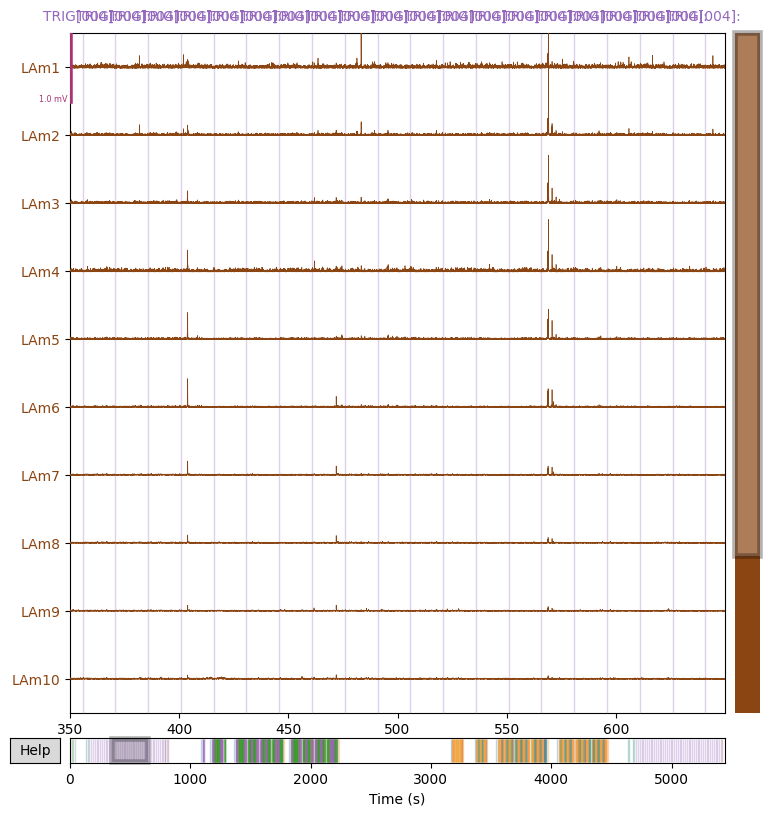

In [14]:
raw_env.plot(
    picks=eeg_channels[0:13],
    duration=300,   # seconds shown at once
    start=350,       # start time in seconds
    n_channels=10,  # how many stacked traces
    scalings={"seeg": 500e-6}
);

In [15]:
import numpy as np
import mne
from numpy.lib.stride_tricks import sliding_window_view

def fit_lognormal_envelope_segments(raw_envelope, win_coeff, overlap_coeff, picks="seeg"):
    """
    Compute log-normal MLE parameters (mu, sigma) for each segment of the
    Hilbert envelope, for each selected channel.

    Parameters
    ----------
    envolope : mne.io.BaseRaw
        MNE Raw envelop object.
    index : array-like of int
        Segment start indices (sample indices).
    winsize : int
        Window length in samples.
    picks : str | array-like
        Channels to use. Default is "seeg".

    Returns
    -------
    mu_hat : ndarray, shape (n_channels, n_segments)
        Estimated mu for each channel and segment.
    sigma_hat : ndarray, shape (n_channels, n_segments)
        Estimated sigma for each channel and segment.
    envelope : ndarray, shape (n_channels, n_times)
        Hilbert envelope used in the computation.
    picked_ch_names : list of str
        Names of the channels that were analyzed.
    """
    envelope = raw_envelope.get_data(picks = picks)
    fs = int(raw_envelope.info["sfreq"])
    winsize = win_coeff*fs
    overlap = overlap_coeff*fs
    step = int(winsize-overlap)
    envelope_len = envelope.shape[1]
    index = np.asarray(range(0,envelope_len ,step), dtype=int)

    # Safety checks
    if np.any(index < 0):
        raise ValueError("All segment start indices must be >= 0.")
    if np.any(index + winsize > envelope_len ):
        index = index[index+winsize <= envelope_len]

    # Build all sliding windows once:
    # shape -> (n_channels, n_possible_starts, winsize)
    all_windows = sliding_window_view(envelope, window_shape=winsize, axis=1)

    # Select only the requested segment starts:
    # shape -> (n_channels, n_segments, winsize)
    segments = all_windows[:, index, :]

    # Remove nonpositive values by replacing them with NaN after log
    # MATLAB: segment(segment<=0) = [];
    with np.errstate(divide="ignore", invalid="ignore"):
        log_segments = np.where(segments > 0, np.log(segments), np.nan)

    # Closed-form MLE for lognormal:
    # mu = mean(log x), sigma = std(log x) with ddof=0
    mu_hat = np.nanmean(log_segments, axis=-1)
    sigma_hat = np.nanstd(log_segments, axis=-1, ddof=0)

    return mu_hat, sigma_hat, index

In [16]:
np.asarray(range(0,raw_env.get_data().shape[1],200)).shape

(5445,)

In [17]:
fs = raw_env.info["sfreq"]
winsize = 5*fs
overlap = 4*fs
step = int(winsize-overlap)
step

200

In [18]:
mu_hat, sigma_hat, index = fit_lognormal_envelope_segments(raw_env, win_coeff=5, overlap_coeff=4, picks="seeg")

In [19]:
plt.plot(mu_hat[2])

#  Pipeline 1, follow the code

In [20]:
#moving average smooth
window_len = 5

mv_avg_kernel = np.ones(window_len)/window_len

mu_hat_smooth = signal.filtfilt(mv_avg_kernel , [1], mu_hat, axis=1)
sigma_hat_smooth = signal.filtfilt(mv_avg_kernel , [1], sigma_hat, axis=1)

In [21]:
plt.plot(mu_hat_smooth[2])

In [22]:
#interpolation of thresholds value to threshold curve (cubic spline)
import numpy as np
from scipy.interpolate import CubicSpline

def interpolate_phat(phat, index, winsize, n_samples):
    """
    Interpolate segment-wise lognormal parameters to sample-wise.
    
    Parameters
    ----------
    phat : ndarray, shape (n_channels, n_segments)
        Either mu_hat or sigma_hat.
    index : ndarray, shape (n_segments,)
        Start sample of each segment.
    winsize : int
        Window size in samples.
    n_samples : int
        Total number of samples in the original signal.
    
    Returns
    -------
    phat_int : ndarray, shape (n_channels, n_samples)
        Interpolated parameters at every sample.
    """
    half_win = round(winsize / 2)
    centers  = index + half_win
    query    = np.arange(centers[0], centers[-1] + 1)

    # phat.T is (n_segments, n_channels) — CubicSpline fits all channels at once
    cs           = CubicSpline(centers, phat.T)
    interpolated = cs(query).T                        # (n_channels, n_interp)

    n_start   = half_win
    n_end     = n_samples - (interpolated.shape[1] + n_start)

    pad_start = np.broadcast_to(interpolated[:, :1],  (interpolated.shape[0], n_start)).copy()
    pad_end   = np.broadcast_to(interpolated[:, -1:], (interpolated.shape[0], n_end)).copy()

    phat_int = np.concatenate([pad_start, interpolated, pad_end], axis=1)

    assert phat_int.shape == (phat.shape[0], n_samples), "Length mismatch — check winsize/index alignment"

    return phat_int

In [23]:
n_samples = raw_env.get_data().shape[1]
window_size = window_len*200

In [24]:
mu_interp = interpolate_phat(mu_hat_smooth, index, window_size, n_samples)
sigma_interp = interpolate_phat(sigma_hat_smooth, index, window_size, n_samples)

In [25]:
time_stamps = index+int(window_size/2)
time = np.arange(n_samples)
mask = (time >= time_stamps[0]) &  (time <= time_stamps[99])

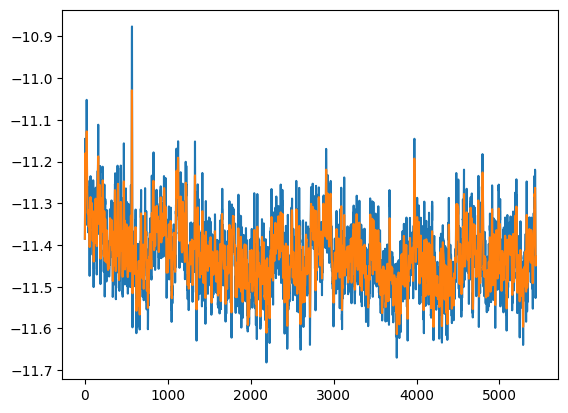

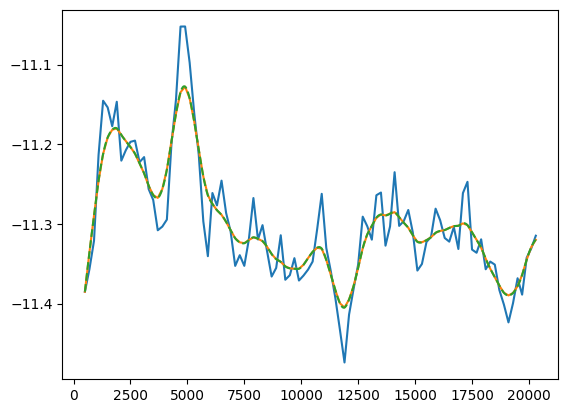

In [26]:
plt.figure()
plt.plot(time_stamps[0:100],mu_hat[2][0:100])
plt.plot(time_stamps[0:100],mu_hat_smooth[2][0:100])
plt.plot(time[mask], mu_interp[2][mask],'--')
plt.show()

In [27]:
#threshold
k = 3.65
logn_mode = np.exp(mu_interp - sigma_interp**2)
logn_median = np.exp(mu_interp)
threshold = k*(logn_mode+logn_median)


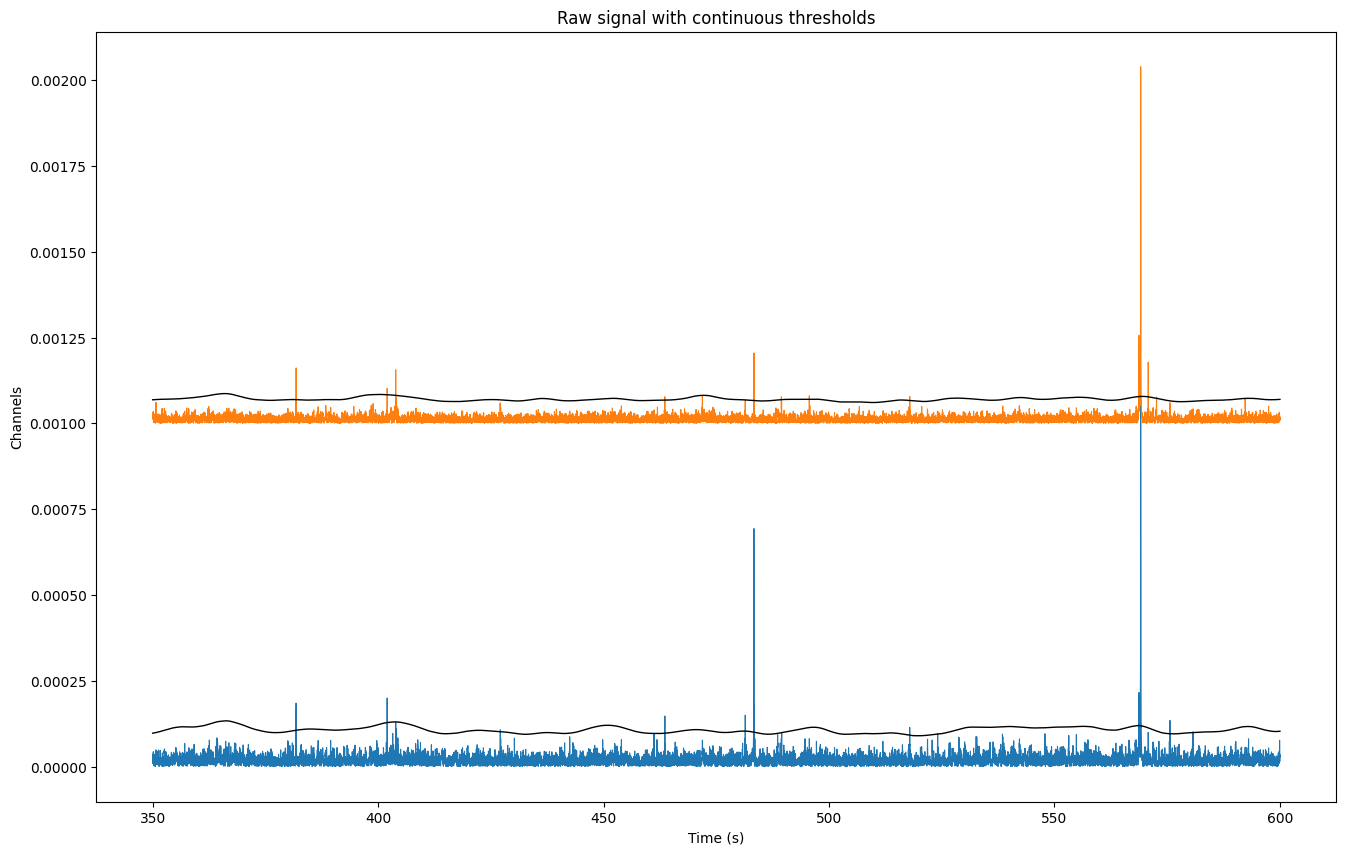

In [28]:
import matplotlib.pyplot as plt
import numpy as np

# example channel subset
ch_idx = list(range(2))   # first 10 channels
start_s = 350
duration_s = 250
sfreq = raw_env.info["sfreq"]

start = int(start_s * sfreq)
stop = int((start_s + duration_s) * sfreq)

data = raw_env.get_data(picks=eeg_channels)[ch_idx, start:stop]
thr  = threshold[ch_idx, start:stop]
times = np.arange(start, stop) / sfreq

n_plot = len(ch_idx)
offset = 1000e-6  # vertical spacing; adjust as needed

plt.figure(figsize=(16, 10))

for i in range(n_plot):
    y = data[i] + i * offset
    t = thr[i] + i * offset

    plt.plot(times, y, linewidth=0.8)
    plt.plot(times, t, 'k', linewidth=1.0)

plt.xlabel("Time (s)")
plt.ylabel("Channels")
plt.title("Raw signal with continuous thresholds")
plt.show()

In [29]:
#calculate envelop CDF and PDfs

from scipy.special import erf
import numpy as np

# envelope:   (n_channels, n_samples)
# mu_int:     (n_channels, n_samples)
# sigma_int:  (n_channels, n_samples)

envelope = raw_env.get_data(picks ="seeg")
log_env = np.log(envelope)

envelope_cdf = 0.5 + 0.5 * erf((log_env - mu_interp) / (np.sqrt(2) * sigma_interp))
envelope_pdf = np.exp(-0.5 * ((log_env - mu_interp) / sigma_interp) ** 2) / (envelope * sigma_interp * np.sqrt(2 * np.pi))

## local_maxima_detection


In [52]:
n_channels = envelope.shape[0]
marker1 = np.zeros([n_channels, n_samples])
marker1[envelope > threshold] = 1

In [53]:
start_crossing = np.where(np.diff(
    np.pad(marker1, ((0,0),(1,0))), axis=1
) > 0)

end_crossing = np.where(np.diff(
    np.pad(marker1, ((0,0),(0,1))), axis=1
) < 0)

In [54]:
marker1.sum()

np.float64(541112.0)

In [55]:
#join together into spikes
spike_markers = np.zeros([n_channels, n_samples])*False
for i in range(start_crossing[0].shape[0]):
    ch = start_crossing[0][i]
    start = start_crossing[1][i]
    end = end_crossing[1][i]
    
    if end - start > 2:
        seg = envelope[ch][start:end+1]
        seg_s = np.sign(np.diff(seg))
        seg_s = np.where(np.diff(np.concatenate(([0], seg_s))) <0 )
        
        spike_markers[ch][start+seg_s]=True
    else:
        seg = envelope[ch][start:end+1]
        s_max = np.argmax(seg)
        
        spike_markers[ch][start+s_max]=True

        
            

In [56]:
spike_markers.sum()

np.float64(77036.0)

In [57]:
# joining spike that occur within a given time fram together
polyspike_union_time = 0.12
sample_wind = int(fs*polyspike_union_time)

spike_pointers = np.where(spike_markers)

In [58]:
spike_found = False
for j in range(spike_pointers[0].shape[0]):
    channel = spike_pointers[0][j]
    pointer = spike_pointers[1][j]
    if pointer+sample_wind > n_samples:
        seg = spike_markers[ch][pointer+1:n_samples]
    else:
        seg = spike_markers[ch][pointer+1:pointer+sample_wind]
        
    if spike_found:
        if np.sum(seg) == 0:
            spike_found = False
            spike_markers[spike_start:pointer+1] = True
    else:
        if sum(seg) > 0:
            spike_found = True
            spike_start = pointer
            
    
    

In [59]:
print(spike_markers.sum())
print(spike_markers.shape)
spike_pointers[1].shape

77036.0
(255, 1088869)


(77036,)

In [60]:
## find the maxima of joint spikes
start_crossing = np.where(np.diff(
    np.pad(spike_markers, ((0,0),(1,0))), axis=1
) > 0)

end_crossing = np.where(np.diff(
    np.pad(spike_markers, ((0,0),(0,1))), axis=1
) < 0)

In [61]:
start_crossing[0].shape

(77036,)

In [63]:

for k in range(start_crossing[0].shape[0]):
    channel = start_crossing[0][k]
    start = start_crossing[1][k]
    end = end_crossing[1][k]
    
    if end - start > 1:
        channel_mask = spike_pointers[0] == chanel
        channel_pointers = spike_pointers[1][channel_mask]
        local_max_mask = (channel_pointers > start) & (channel_pointers <= end)
        local_max = channel_pointers[local_max_mask]
        spike_markers[channel][start:end+1] = False
        
        local_max_val = envelope[channel][local_max]
        local_max_pos = np.diff(np.sign(np.diff(np.concatentate(([0],local_max_val,[0])))) <0)
        spike_markers[channel][local_max[local_max_poz]] = True

77036.0
(255, 200)


(array([  0,   0,   0, ..., 254, 254, 254], shape=(77036,)),
 array([ 31708,  37573,  43370, ..., 619870, 858021, 953416],
       shape=(77036,)))

In [71]:
fs = int(fs)
spike_markers[:, 0:fs] = False
spike_markers[:, -fs+1:] = False
print(spike_markers.sum())
fs

77005.0


200

### Obvious spike count and spike rate / min

In [80]:
channel_spike_counts = spike_markers.sum(axis=1)
time_min = spike_markers.shape[1]/200/60
channel_spike_rate = channel_spike_counts/time_min
print(sum(channel_spike_rate>6.5)/255*100)

13.725490196078432


# Notch comparisons

In [42]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
import mne

# -----------------------------
# Settings
# -----------------------------
fs = 1000          # sampling frequency in Hz
f0 = 60            # line frequency
r = 0.985          # pole radius from the paper
n = 65536          # impulse length for estimating frequency response

# -----------------------------
# 1) Paper-style custom biquad notch
#    zeros at e^{±jw0}, poles at r*e^{±jw0}
# -----------------------------
w0 = 2 * np.pi * f0 / fs

b_custom = np.array([1, -2 * np.cos(w0), 1], dtype=float)
a_custom = np.array([1, -2 * r * np.cos(w0), r**2], dtype=float)

# Normalize so gain at DC is 1
_, h0 = signal.freqz(b_custom, a_custom, worN=[0], fs=fs)
b_custom = b_custom / np.abs(h0[0])

# -----------------------------
# 2) MNE notch filter responses
#    We estimate frequency response by filtering an impulse
# -----------------------------
impulse = np.zeros(n)
impulse[n // 2] = 1.0  # center the impulse instead of index 0

h_mne_60 = mne.filter.notch_filter(
    impulse.copy().reshape(1, -1),  # shape (1, n)
    Fs=fs,
    freqs=[60],
    method="iir",
    verbose=False
).squeeze()  # back to 1D


# Custom biquad impulse response
h_custom = signal.filtfilt(b_custom, a_custom, impulse)

# -----------------------------
# Convert impulse responses to frequency responses
# -----------------------------
freqs = np.fft.rfftfreq(n, d=1/fs)

H_custom = np.fft.rfft(h_custom)
H_mne_60 = np.fft.rfft(h_mne_60)
H_custom_mne = np.fft.rfft(h_custom_mne)

def mag_db(H):
    return 20 * np.log10(np.maximum(np.abs(H), 1e-12))

mag_custom = mag_db(H_custom)
mag_mne_60 = mag_db(H_mne_60)
mag_custom_mne = mag_db(H_custom_mne)



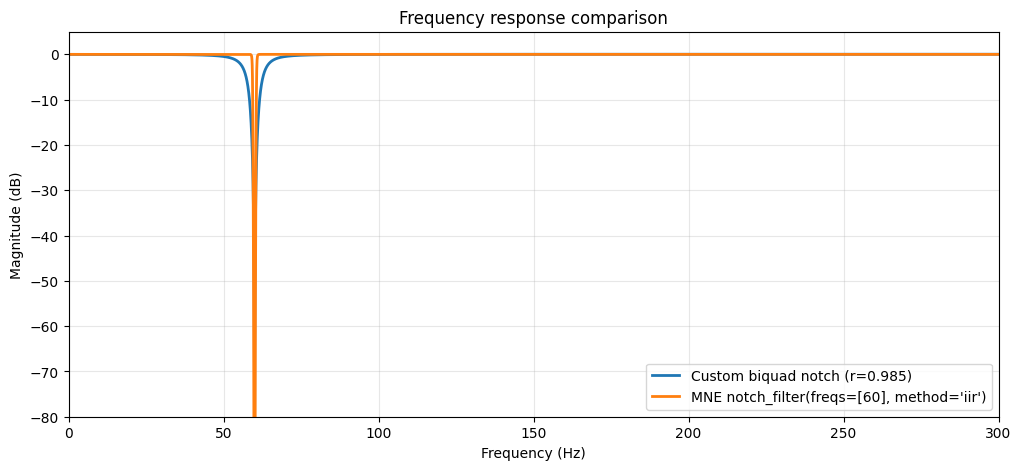

In [43]:
# -----------------------------
# Plot 1: full spectrum
# -----------------------------
plt.figure(figsize=(12, 5))
plt.plot(freqs, mag_custom, label="Custom biquad notch (r=0.985)", linewidth=2)
plt.plot(freqs, mag_mne_60, label="MNE notch_filter(freqs=[60], method='iir')", linewidth=2)
plt.xlim(0, 300)
plt.ylim(-80, 5)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude (dB)")
plt.title("Frequency response comparison")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()



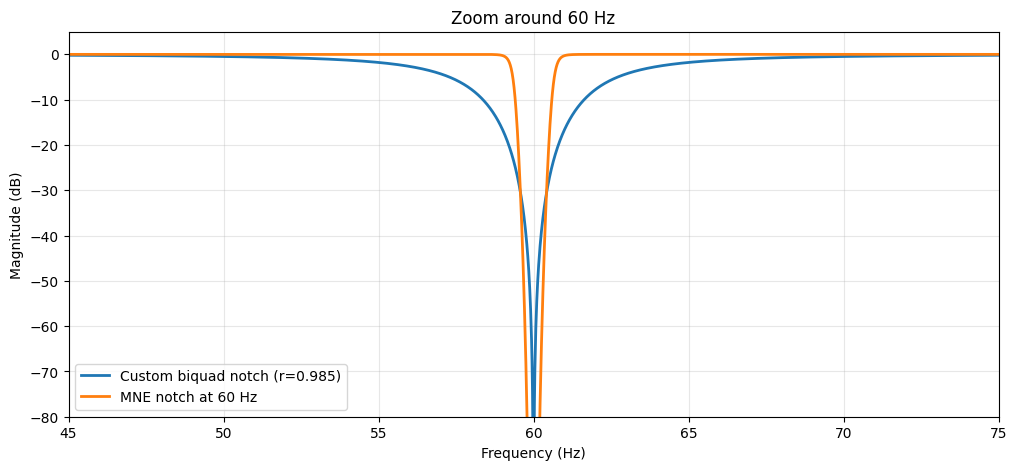

In [44]:
# -----------------------------
# Plot 2: zoom around 60 Hz
# -----------------------------
plt.figure(figsize=(12, 5))
plt.plot(freqs, mag_custom, label="Custom biquad notch (r=0.985)", linewidth=2)
plt.plot(freqs, mag_mne_60, label="MNE notch at 60 Hz", linewidth=2)
plt.xlim(45, 75)
plt.ylim(-80, 5)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude (dB)")
plt.title("Zoom around 60 Hz")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()



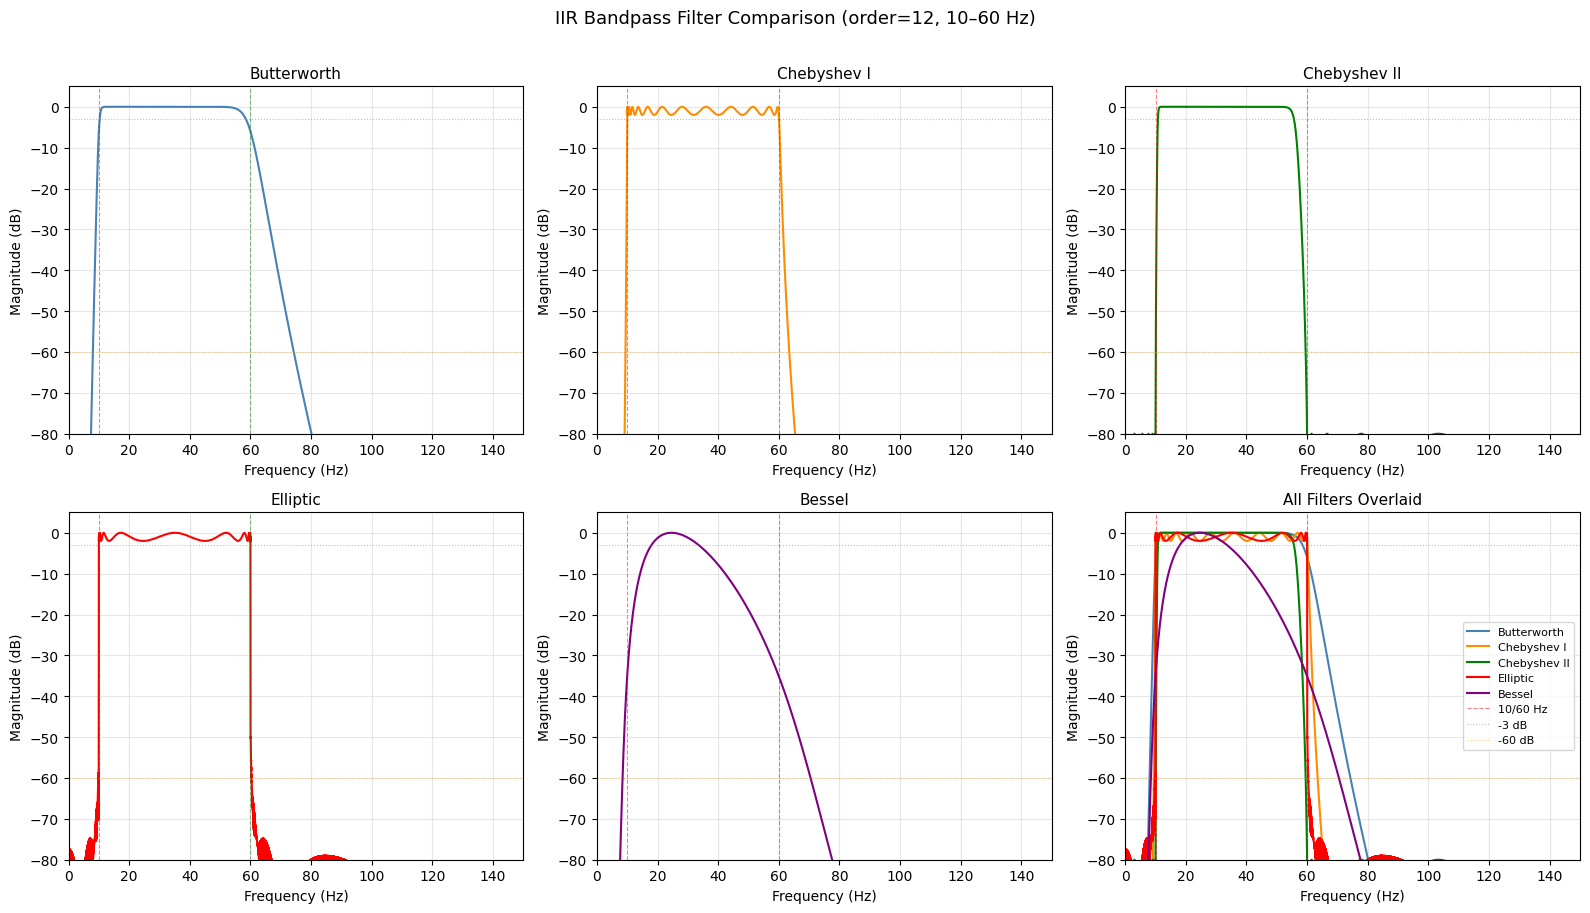

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import mne

# -----------------------------
# Settings
# -----------------------------
fs = 1000
n = 65536
order = 12
rp=1
rs=40

filter_configs = [
    ("Butterworth",        dict(order=order, ftype="butter")),
    ("Chebyshev I",        dict(order=order, ftype="cheby1", rp=rp)),
    ("Chebyshev II",       dict(order=order, ftype="cheby2", rs=rs)),
    ("Elliptic",           dict(order=order, ftype="ellip",  rp=rp, rs=rs)),
    ("Bessel",             dict(order=order, ftype="bessel")),
]

colors = ['steelblue', 'darkorange', 'green', 'red', 'purple']

# -----------------------------
# Impulse
# -----------------------------
impulse = np.zeros(n)
impulse[n // 2] = 1.0

# -----------------------------
# Filter each and collect responses
# -----------------------------
freqs = np.fft.rfftfreq(n, d=1/fs)

def mag_db(H):
    return 20 * np.log10(np.maximum(np.abs(H), 1e-12))

responses = []
for name, iir_params in filter_configs:
    h = mne.filter.filter_data(
        impulse.copy().reshape(1, -1),
        sfreq=fs,
        l_freq=10,
        h_freq=60,
        method="iir",
        iir_params=iir_params,
        verbose=False
    ).squeeze()
    h = np.roll(h, -n // 2)
    H = mag_db(np.fft.rfft(h))
    responses.append(H)

# -----------------------------
# Plot: 5 individual + 1 overlay
# -----------------------------
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, (name, _) in enumerate(filter_configs):
    ax = axes[i]
    ax.plot(freqs, responses[i], color=colors[i], linewidth=1.5)
    ax.axvline(10, color='r',    linestyle='--', alpha=0.5, linewidth=0.8)
    ax.axvline(60, color='g',    linestyle='--', alpha=0.5, linewidth=0.8)
    ax.axhline(-3,  color='gray',   linestyle=':',  alpha=0.5, linewidth=0.8)
    ax.axhline(-60, color='orange', linestyle=':',  alpha=0.5, linewidth=0.8)
    ax.set_xlim(0, 150)
    ax.set_ylim(-80, 5)
    ax.set_title(name, fontsize=11)
    ax.set_xlabel('Frequency (Hz)')
    ax.set_ylabel('Magnitude (dB)')
    ax.grid(True, alpha=0.3)

# Overlay subplot
ax = axes[5]
for i, (name, _) in enumerate(filter_configs):
    ax.plot(freqs, responses[i], color=colors[i], linewidth=1.5, label=name)
ax.axvline(10, color='r',    linestyle='--', alpha=0.5, linewidth=0.8, label='10/60 Hz')
ax.axvline(60, color='r',    linestyle='--', alpha=0.5, linewidth=0.8)
ax.axhline(-3,  color='gray',   linestyle=':',  alpha=0.5, linewidth=0.8, label='-3 dB')
ax.axhline(-60, color='orange', linestyle=':',  alpha=0.5, linewidth=0.8, label='-60 dB')
ax.set_xlim(0, 150)
ax.set_ylim(-80, 5)
ax.set_title("All Filters Overlaid", fontsize=11)
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('Magnitude (dB)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

fig.suptitle(f"IIR Bandpass Filter Comparison (order={order}, 10–60 Hz)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()